# 14_train_evaluate_supervised_ML_models

Run supervised ML training/evaluation across feature combinations, split types, and model choices.

## 1) Environment Setup


In [1]:
from pathlib import Path
import sys

# Section 1: Resolve repo root from either project root or notebooks/ cwd.
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

# Section 2: Add repo and src roots to sys.path for imports.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root:", repo_root)
print("src_root:", src_root)


repo_root: /Users/charmainechia/Documents/projects/agentic-protein-design
src_root: /Users/charmainechia/Documents/projects/agentic-protein-design/src


## 2) Imports


In [2]:
from pprint import pprint

import agentic_protein_design.steps.train_evaluate_supervised_ml_models as ml_step
from project_config.feature_registry import COMBI_ML_FEATURE_SETS
from project_config.variables import address_dict

train_evaluate_supervised_ml_models = ml_step.train_evaluate_supervised_ml_models
default_user_inputs = ml_step.default_user_inputs

## 3) Optional Data Segmentation


In [3]:
from tools.ml.data_segmentation import run_data_segmentation

# Optional: run segmentation before ML.
segmentation_inputs = {
    'run_segmentation': False,
    'root_key': 'MUTAGENESIS-DATA-BENCHMARKS',
    'data_subfolder': 'D7PM05_CLYGR_Somermeyer_2022',
    'csv_file': 'D7PM05_CLYGR_Somermeyer_2022.csv',
    'output_csv_file': 'D7PM05_CLYGR_Somermeyer_2022_3.csv',  # optional override
    'k_folds': 5,
    'mutation_separator': ':',
    'num_mutation_segments_singlemut': 5,
    'min_layer_size_for_multimut_segmentation': 400,
    'smallest_single_mutant_size': 70,
    'include_mutation_onehot_for_clustering': True,
    'verbose': True,
}

segmentation_result = {'status': 'skipped', 'output_dataset_fname': None}
if segmentation_inputs['run_segmentation']:
    csv_dir = (repo_root / Path(address_dict[segmentation_inputs['root_key']]) / 'expdata' / segmentation_inputs['data_subfolder']).resolve()
    payload = dict(segmentation_inputs)
    payload['csv_dir'] = str(csv_dir)
    segmentation_result = run_data_segmentation(payload)

print(segmentation_result)


{'status': 'skipped', 'output_dataset_fname': None}


## 4) Configure ML Inputs


In [4]:
user_inputs = default_user_inputs()

# Edit these for your run
user_inputs['root_key'] = 'MUTAGENESIS-DATA-BENCHMARKS' # 'examples' # 'ECOHARVEST' #
user_inputs['data_fbase'] = user_inputs['root_key']
user_inputs['data_subfolder'] = 'D7PM05_CLYGR_Somermeyer_2022' # 'ET096_R1-2' # 'RML_R1' #
default_dataset_fname = user_inputs['data_subfolder'] + '_2.csv'
user_inputs['dataset_fname'] = segmentation_result.get('output_dataset_fname') or default_dataset_fname

# Experimental data parent folder: address_dict[root_key] / "expdata" / data_subfolder
expdata_dir = (repo_root / Path(address_dict[user_inputs['root_key']]) / 'expdata' / user_inputs['data_subfolder']).resolve()
user_inputs['input_filename_prefix'] = user_inputs['data_subfolder'] + '_' # ''
user_inputs['sequence_base'] = 'sequences/D7PM05_CLYGR_Somermeyer_2022.fasta' # "sequences/ET096.fasta"
# user_inputs['sequence_base'] = 'MVPIKRQSNSTVDSLPPLIPSRTSAPSSSPSTTDPEAPAMSRNGPLPSDVETKYGMALNATSYPDSVVQAMSIDGGIRAATSQEINELTYYTTLSANSYCRTVIPGATWDCIHCDATEDLKIIKTWSTLIYDTNAMVARGDSEKTIYIVFRGSSSIRNWIADLTFVPVSYPPVSGTKVHKGFLDSYGEVQNELVATVLDQFKQYPSYKVAVTGHSLGGATALLCALDLYQREEGLSSSNLFLYTQGQPRVGDPAFANYVVSTGIPYRRTVNERDIVPHLPPAAFGFLHAGEEYWITDNSPETVQVCTSDLETSDCSNSIVPFTSVLDHLSYFGINTGLCT'  # or amino-acid string, or FASTA filename/path
user_inputs['target_col'] = ['DMS_score'] # [f'foldchange_{s}_activity_25C' for s in ['NBD','ABTS']] # ['foldchange_TSO'] #
user_inputs['classification_or_regression'] = 'regression'
user_inputs['csv_suffix'] = '_1'

# specify splits
user_inputs['split_type_list'] = ['mutres-modulo', 'custom'] # ['random', 'custom'] #
user_inputs['k_folds'] = 5
user_inputs['random_split_col'] = f'fold_random_{user_inputs["k_folds"]}'
user_inputs['mutres_split_col'] = f'fold_mutres-modulo_{user_inputs["k_folds"]}'
user_inputs['contiguous_split_col'] = f'fold_contiguous_{user_inputs["k_folds"]}'  # optional precomputed column
user_inputs['custom_split_col'] = 'fold_custom'
user_inputs['custom_test_value'] = 1

# specify custom dataset name
user_inputs['custom_test_dataset_fname'] = None # 'ET096_R3.csv' # ''
user_inputs['custom_test_data_subfolder'] = user_inputs['data_subfolder']
user_inputs['custom_input_filename_prefix'] = None if user_inputs['custom_test_dataset_fname'] is None else user_inputs['custom_test_dataset_fname'].split('.')[0] # ''

# specify featureset combinations to test
# user_inputs['feature_combinations_dict'] = COMBI_ML_FEATURE_SETS
user_inputs['feature_combinations_dict'] = {
    'onehot_esm2_LLR': ['one_hot', 'esm2-650m_LLR-masked'],
    'georgiev_esm2_LLR': ['georgiev', 'esm2-650m_LLR-masked'],
    'esm2_seq_embeddings_LLR': ['esm2-650m_mean_pooled-33', 'esm2-650m_LLR-masked'],
}

# specify models
user_inputs['model_list'] = ['ridge', 'xgboost'] # ['mlp_sklearn', 'mlp_pytorch'] #

# run parameters
user_inputs['save_trained_models'] = False
user_inputs['save_predictions'] = False
user_inputs['train_full_data_model'] = False
user_inputs['featurecombi_model_pair_to_extract_coefficients_for'] = None # [('onehot', 'ridge')]
user_inputs['show_progress'] = True
pprint(user_inputs)


{'classification_or_regression': 'regression',
 'contiguous_split_col': 'fold_contiguous_5',
 'csv_suffix': '_1',
 'custom_input_filename_prefix': None,
 'custom_split_col': 'fold_custom',
 'custom_test_data_subfolder': 'D7PM05_CLYGR_Somermeyer_2022',
 'custom_test_dataset_fname': None,
 'custom_test_value': 1,
 'data_fbase': 'MUTAGENESIS-DATA-BENCHMARKS',
 'data_subfolder': 'D7PM05_CLYGR_Somermeyer_2022',
 'dataset_fname': 'D7PM05_CLYGR_Somermeyer_2022_2.csv',
 'feature_combinations_dict': {'esm2_seq_embeddings_LLR': ['esm2-650m_mean_pooled-33',
                                                           'esm2-650m_LLR-masked'],
                               'georgiev_esm2_LLR': ['georgiev',
                                                     'esm2-650m_LLR-masked'],
                               'onehot_esm2_LLR': ['one_hot',
                                                   'esm2-650m_LLR-masked']},
 'featurecombi_model_pair_to_extract_coefficients_for': None,
 'input_filename_pr

## 5) Run Training And Evaluation


In [4]:
result = train_evaluate_supervised_ml_models(user_inputs)
pprint(result)

[eval-start] target_col=DMS_score | split_type=mutres-modulo | feature_combi_name=onehot_esm2_LLR | model_name=ridge
[fold-result] split_id=0 | split_name=mutres-modulo_fold_0 | split_type=mutres-modulo | eval_group=segments_0_to_0 | data_size_n=52 | segments_included=[0] | n_train=38 | n_test=14
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.2967        0.3759  -0.3268 13753.6357          0.8697          0.968    0.8126   3902.6365
[eval-start] target_col=DMS_score | split_type=mutres-modulo | feature_combi_name=onehot_esm2_LLR | model_name=xgboost
[fold-result] split_id=0 | split_name=mutres-modulo_fold_0 | split_type=mutres-modulo | eval_group=segments_0_to_0 | data_size_n=52 | segments_included=[0] | n_train=38 | n_test=14
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.3545        0.3847  -0.6797  15474.834          0.9997            1.0       1.0     18

/Users/charmainechia/miniconda3/envs/agentic-protein-design/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0074397494008736e-07.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


[fold-result] split_id=60 | split_name=mutres-modulo_fold_0 | split_type=mutres-modulo | eval_group=segments_0_to_12 | data_size_n=15527 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12] | n_train=12413 | n_test=3114
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.9008        0.8505   0.7005   6748.644          0.9349         0.9055    0.8199   5218.7436
[eval-start] target_col=DMS_score | split_type=mutres-modulo | feature_combi_name=georgiev_esm2_LLR | model_name=xgboost
[fold-result] split_id=60 | split_name=mutres-modulo_fold_0 | split_type=mutres-modulo | eval_group=segments_0_to_12 | data_size_n=15527 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12] | n_train=12413 | n_test=3114
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
         0.802        0.8153   0.6285  7517.0117          0.8509          0.875    0.6784   6973.7701
[eval-start] target_col=DMS_score |

/Users/charmainechia/miniconda3/envs/agentic-protein-design/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.000930183181481e-07.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


[fold-result] split_id=61 | split_name=mutres-modulo_fold_1 | split_type=mutres-modulo | eval_group=segments_0_to_12 | data_size_n=15527 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12] | n_train=12403 | n_test=3124
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.9142        0.8515   0.7083  6806.3228          0.9346         0.9052    0.8193   5181.1729
[eval-start] target_col=DMS_score | split_type=mutres-modulo | feature_combi_name=georgiev_esm2_LLR | model_name=xgboost
[fold-result] split_id=61 | split_name=mutres-modulo_fold_1 | split_type=mutres-modulo | eval_group=segments_0_to_12 | data_size_n=15527 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12] | n_train=12403 | n_test=3124
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.8477        0.8155   0.6206  7762.1655          0.8448         0.8758    0.6851   6839.8776
[eval-start] target_col=DMS_score |

...

[fold-result] split_id=18 | split_name=custom_segment_19 | split_type=custom | eval_group=segments_0_to_19 | data_size_n=22801 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19] | n_train=22217 | n_test=584
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.4909        0.5968  -1.1629 11196.0411          0.9058         0.8529    0.7275   6532.8214
[eval-start] target_col=DMS_score | split_type=custom | feature_combi_name=georgiev_esm2_LLR | model_name=xgboost
[fold-result] split_id=18 | split_name=custom_segment_19 | split_type=custom | eval_group=segments_0_to_19 | data_size_n=22801 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19] | n_train=22217 | n_test=584
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.4533         0.566  -0.1155  8040.3421          0.8574          0.842    0.6359   7551.2152
[eval-start] target_co

/Users/charmainechia/miniconda3/envs/agentic-protein-design/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.5468087961353376e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


[fold-result] split_id=19 | split_name=custom_segment_20 | split_type=custom | eval_group=segments_0_to_20 | data_size_n=24163 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20] | n_train=22801 | n_test=1362
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.1424        0.3697 -13.3366 16823.9801          0.9023         0.8474     0.718   6649.4624
[eval-start] target_col=DMS_score | split_type=custom | feature_combi_name=georgiev_esm2_LLR | model_name=xgboost
[fold-result] split_id=19 | split_name=custom_segment_20 | split_type=custom | eval_group=segments_0_to_20 | data_size_n=24163 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20] | n_train=22801 | n_test=1362
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.1588        0.3312  -2.7476  8601.7204          0.8572         0.8393    0.6327   7589.3697
[eval-start] t

/Users/charmainechia/miniconda3/envs/agentic-protein-design/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.05753119991914e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


[fold-result] split_id=20 | split_name=custom_segment_21 | split_type=custom | eval_group=segments_0_to_21 | data_size_n=24515 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21] | n_train=24163 | n_test=352
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.1001        0.1958 -61.2292 20226.0539          0.8829         0.8194    0.6715   7183.6881
[eval-start] target_col=DMS_score | split_type=custom | feature_combi_name=georgiev_esm2_LLR | model_name=xgboost
[fold-result] split_id=20 | split_name=custom_segment_21 | split_type=custom | eval_group=segments_0_to_21 | data_size_n=24515 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21] | n_train=24163 | n_test=352
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.1154        0.1633 -13.9309   9907.328          0.8524         0.8269    0.6203     7722.97
[eval-star

## 6) Visualize ML Results


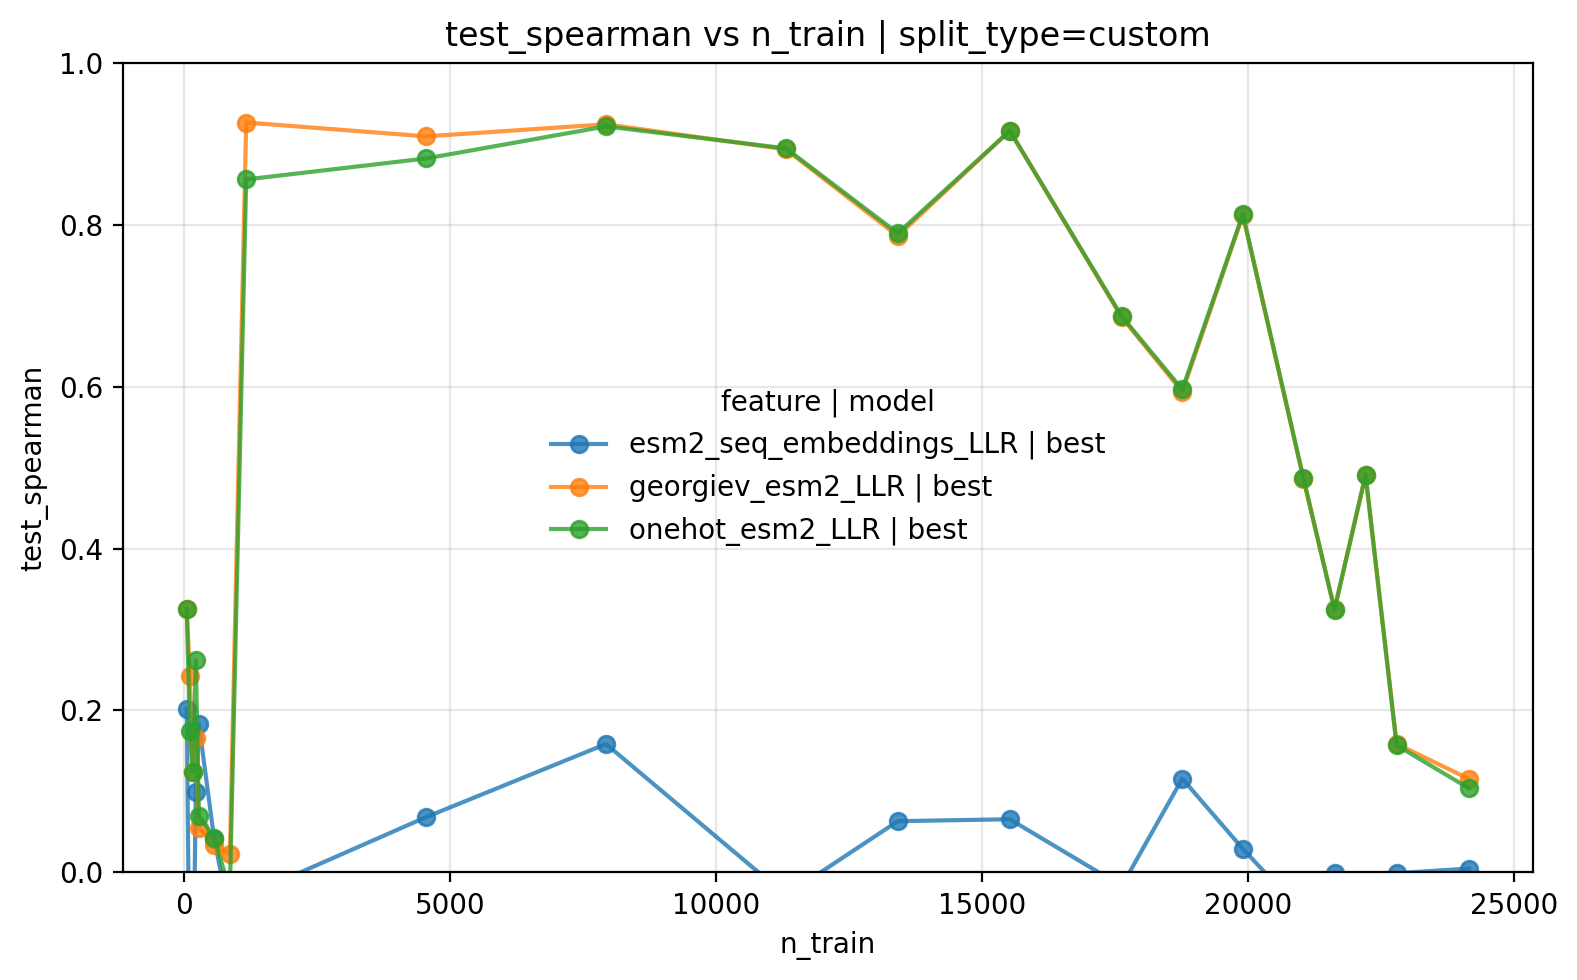

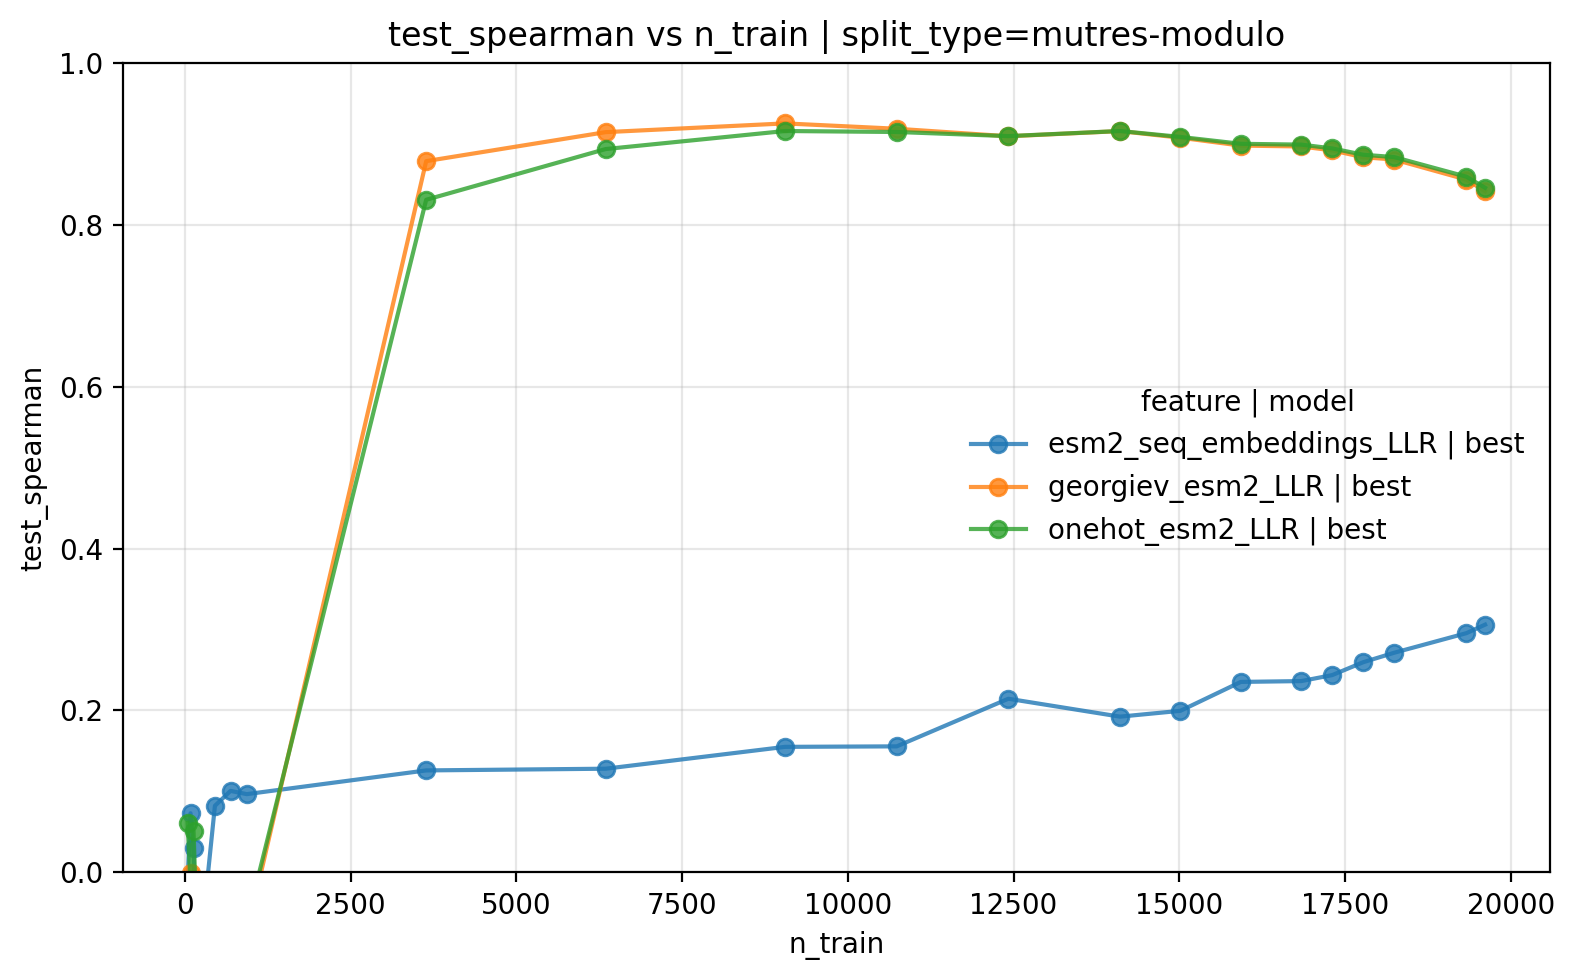

{'figure_paths': ['/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/data_efficiency_test_spearman_custom_best.png',
                  '/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/data_efficiency_test_spearman_mutres-modulo_best.png'],
 'metric_col_list': ['test_spearman'],
 'n_filtered_rows': 258,
 'n_plot_rows_total': 129,
 'n_summary_rows': 258,
 'plotted_pairs': [{'metric_col': 'test_spearman',
                    'n_lines': 3,
                    'n_rows': 63,
                    'split_type': 'custom'},
                   {'metric_col': 'test_spearman',
                    'n_lines': 3,
                    'n_rows': 66,
                    'split_type': 'mutres-modulo'}],
 'skipped_pairs': [],
 'split_type_list': ['custom', 'mutres-modulo'],
 'status': 'ok',
 'summary_csv_path': '/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM0

In [10]:
from pprint import pprint

import agentic_protein_design.steps.visualize_ml_results as ml_viz_step

visualize_ml_results = ml_viz_step.visualize_ml_results
default_viz_inputs = ml_viz_step.default_user_inputs

viz_inputs = default_viz_inputs()
viz_inputs['data_fbase'] = user_inputs.get('data_fbase', 'examples')
viz_inputs['data_subfolder'] = user_inputs.get('data_subfolder', '')
viz_inputs['metrics_summary_fname'] = f"{user_inputs['classification_or_regression']}_metrics_summary{user_inputs.get('csv_suffix', '')}.csv"
viz_inputs['model_name_list'] = ['best']  # e.g. ['xgboost', 'ridge', 'best']
viz_inputs['metric_col'] = ['test_spearman']  # string or list
viz_inputs['split_type_list'] = []  # [] -> iterate all split types in summary CSV
viz_inputs['feature_label_list'] = list(user_inputs['feature_combinations_dict'].keys())
viz_inputs['save_figure'] = True
viz_inputs['show_figure'] = True
viz_inputs['figure_output_dir'] = ''  # default: summary csv folder
viz_inputs['figure_fname'] = ''       # default auto name
viz_inputs['y_limits'] = [0, 1]      # e.g. [0.0, 1.0]; None/[] uses matplotlib defaults

# Optional override:
# viz_inputs['metrics_summary_csv_path'] = '/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/Q65J43_BACLD_g4_Thomas_2025/regression_metrics_summary_2.csv'

viz_result = visualize_ml_results(viz_inputs)
pprint(viz_result)
